In [1]:
# SPDX-License-Identifier: CC-BY-4.0
# Code for "Active Continual Learning with Metaplastic Binary Bayesian Neural Networks"
# Kellian Cottart, Théo Ballet, Djohan Bonnet, Damien Querlioz
# Portions of the code are adapted from the Pytorch project (BSD-3-Clause)
# Author: Kellian Cottart <kellian.cottart@gmail.com>
# Date: 2025-30-01

In [2]:

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import os
import seaborn as sns
import re
import json
import pandas as pd
AXESSIZE = 28
FONTSIZE = 26
TICKSIZE = 24   
LEGENDSIZE = 26
plt.rcParams['svg.fonttype'] = 'none'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.05"
FOLDER = "figures-appendix-pmnist-N-study"
os.makedirs(FOLDER, exist_ok=True)
results_folder = "results-appendix-pmnist-N-study"
df = pd.DataFrame()
# iterate through all root folders in the results folder
for folder in os.listdir(results_folder):
    current_path = os.path.join(results_folder, folder)
    # extract the name from the first config
    config_path = os.path.join(current_path, "config0/config.json")
    with open(config_path, "r") as f:
        config = json.load(f)
    # n_iterations is the number of config folders
    n_iterations = len([f for f in os.listdir(current_path) if f.startswith("config") and os.path.isdir(os.path.join(current_path, f))])
    
    # Add the row of parameters to the dataframe   
    field = [key for key in config.keys() if "ewc" in key]
    field_si = [key for key in config.keys() if key=="si"]
    row = {
        "path": current_path,
        "opt": config["optimizer"] if config["optimizer"] != "bimu" else config["optimizer"] + "-" + str(int(config["optimizer_params"]["N"])),
        "n_tasks": config["n_tasks"],
        "n_epochs": config["epochs"],
        "n_train_samples": config["n_train_samples"] if "n_train_samples" in config else 1,
        "n_test_samples": config["n_test_samples"] if "n_test_samples" in config else 1,
        "n_iterations": n_iterations,
        "batch_size": config["train_batch_size"],
        "method": list(config["network_params"]["active_learning"].keys())[0] if "active_learning" in config["network_params"] else "none",
        "N": str(int(config["optimizer_params"]["N"])) if "N" in config["optimizer_params"] else "1000000000",
        # key containing ewc but not strictly equal to ewc
        "ewc": config[field[0]] if len(field) > 0 else "none",
        "si": config[field_si[0]] if len(field_si) > 0 else "none",
    }
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

# One color for each path
colors = sns.color_palette("viridis", len(df["method"].unique()))
markers = ["D", "o", "s", "h", "^", "x", "v", "p", "*", "X", "D", "o", "s", "h", "^", "x", "v", "p", "*", "X"]

In [3]:
data = []
for idx, row in df.iterrows():
    path = row["path"]
    n_tasks = row["n_tasks"]
    n_epochs = row["n_epochs"]
    n_iterations = row["n_iterations"]
    full_accuracies = []
    full_roc_aucs = []
    full_footprint = []
    full_weights_layer_0 = []
    full_weights_layer_1 = []
    for it in range(n_iterations):
        current_it_path = os.path.join(path, f"config{it}")
        accuracy_path = os.path.join(current_it_path, "accuracy")
        uncertainty_path = os.path.join(current_it_path, "uncertainty")
        weights_path = os.path.join(current_it_path, "weights")
        accuracies = []
        roc_aucs = []
        for task in range(n_tasks):
            for epoch in range(n_epochs):
                suffix = f"task={task}-epoch={epoch}.npy"
                accuracies.append(jnp.load(os.path.join(accuracy_path, "split=0-"+suffix)))
                epistemic_u = jnp.load(os.path.join(uncertainty_path, f"roc-auc-epistemic-{suffix}"))
                aleatoric_u = jnp.load(os.path.join(uncertainty_path, f"roc-auc-aleatoric-{suffix}"))
                roc_aucs.append(epistemic_u if epistemic_u != 0.0 else aleatoric_u)
        full_footprint.append(jnp.load(os.path.join(current_it_path, "memory_occupation.npy")))
        full_accuracies.append(jnp.array(accuracies))
        full_roc_aucs.append(jnp.array(roc_aucs))
        full_weights_layer_0.append(jnp.load(os.path.join(weights_path, "layer=0.npy")))
        full_weights_layer_1.append(jnp.load(os.path.join(weights_path, "layer=1.npy")))
    full_accuracies = jnp.array(full_accuracies)*100
    accuracy_array_mean = jnp.mean(full_accuracies, -1)[:, -1].mean(0)
    accuracy_array_std = jnp.mean(full_accuracies, -1)[:, -1].std(0)
    full_roc_aucs = jnp.array(full_roc_aucs)
    full_footprint = jnp.array(full_footprint)
    full_weights_layer_0 = jax.nn.sigmoid(2*jnp.array(full_weights_layer_0))
    full_weights_layer_1 = jax.nn.sigmoid(2*jnp.array(full_weights_layer_1))
    data.append((full_accuracies, full_accuracies[:, -1, :], full_roc_aucs, full_accuracies[:, 0, :], full_footprint.mean(0), full_weights_layer_0, full_weights_layer_0))
# Add new columns to df
df["accuracies"] = [d[0] for d in data]
df["last_accuracies"] = [d[1] for d in data]
df["roc_aucs"] = [d[2] for d in data]
df["first_accuracies"] = [d[3] for d in data]
df["footprint"] = [d[4] for d in data]
df["layer0"]= [d[5] for d in data]
df["layer1"]= [d[6] for d in data]


In [7]:
def make_key(row):
    key = row["opt"]
    if row["ewc"] != "none":
        key += "-ewc"
    if row["si"] != "none":
        key += "-si"
    if key == "adam":
        key = "STE"
    return key


rows = {}

for _, row in df.iterrows():
    key = make_key(row)

    last_accuracies = row["last_accuracies"][:, -5:]
    acc_per_run = jnp.mean(last_accuracies, axis=-1)
    acc_mean = acc_per_run.mean()
    acc_std = acc_per_run.std()

    roc_aucs = row["roc_aucs"]
    auc_mean = roc_aucs[-1].mean()
    auc_std = roc_aucs[-1].std()

    last_acc = row["last_accuracies"].mean(0)[-1] / 100
    first_acc = row["first_accuracies"].mean(0)[0] / 100
    memory_rigidity = 1.0 / jnp.abs(last_acc - first_acc)
    
    last_20_accuracies = row["last_accuracies"][:, -20:]
    acc_per_run_20 = jnp.mean(last_20_accuracies, axis=-1)
    acc_mean_20 = acc_per_run_20.mean()
    acc_std_20 = acc_per_run_20.std()
    
    last_100_accuracies = row["last_accuracies"][:, -100:]
    acc_per_run_100 = jnp.mean(last_100_accuracies, axis=-1)
    acc_mean_100 = acc_per_run_100.mean()
    acc_std_100 = acc_per_run_100.std()

    rows[key] = {
        "Average 5 last tasks (%)": f"${acc_mean:.2f} \\pm {acc_std:.2f}$",
        "Average 20 last tasks (%)": f"${acc_mean_20:.2f} \\pm {acc_std_20:.2f}$",
        "Average 100 last tasks (%)": f"${acc_mean_100:.2f} \\pm {acc_std_100:.2f}$",
        "Fashion-MNIST OOD detection (ROC-AUC)": f"${auc_mean:.4f} \\pm {auc_std:.4f}$",
        "Maximum Memory Rigidity Resilience": f"${memory_rigidity:.4f}$",
    }


combined_table = pd.DataFrame.from_dict(rows, orient="index")
combined_table.index = (
    combined_table.index
    .str.replace("bayesbinn", "Bayes BiNN")
    .str.replace("bimu", "BiMU")
    .str.replace("mesu", "MESU")
    .str.replace("adamw", "Adam")
    .str.replace("adam", "STE")
    .str.replace("sgd-ewc", "EWC Online")
    .str.replace("sgd-si", "Synaptic Intelligence")
    .str.replace("sgd", "SGD")
    .str.replace("synapticmetaplasticity", "Synaptic Metaplasticity")
)
combined_table

,Average 5 last tasks (%),Average 20 last tasks (%),Average 100 last tasks (%),Fashion-MNIST OOD detection (ROC-AUC),Maximum Memory Rigidity Resilience
Bayes BiNN,$67.91 \pm 0.96$,$55.74 \pm 0.49$,$25.46 \pm 0.42$,$0.7466 \pm 0.2024$,$5.2203$
BiMU-100000,$83.70 \pm 0.30$,$75.29 \pm 0.68$,$38.24 \pm 0.90$,$0.9398 \pm 0.0478$,$13.5318$
BiMU-1900,$86.55 \pm 0.24$,$75.79 \pm 1.08$,$33.93 \pm 0.55$,$0.9633 \pm 0.0233$,$21.9299$
BiMU-1600,$86.94 \pm 0.29$,$75.82 \pm 0.43$,$33.13 \pm 0.45$,$0.9644 \pm 0.0216$,$26.4831$
BiMU-1300,$87.67 \pm 0.33$,$75.47 \pm 0.28$,$31.68 \pm 0.56$,$0.9747 \pm 0.0204$,$30.2298$
BiMU-1000,$89.07 \pm 0.28$,$73.69 \pm 0.83$,$28.61 \pm 0.09$,$0.9787 \pm 0.0148$,$52.7425$
BiMU-700,$90.29 \pm 0.24$,$58.29 \pm 0.51$,$20.81 \pm 0.18$,$0.9920 \pm 0.0064$,$862.1385$
BiMU-400,$73.46 \pm 2.59$,$27.87 \pm 0.79$,$13.53 \pm 0.15$,$0.9952 \pm 0.0045$,$175.4370$
BiMU-100,$27.09 \pm 0.57$,$14.09 \pm 0.26$,$10.79 \pm 0.11$,$0.9950 \pm 0.0030$,$354.6081$


In [5]:
# concat layer 0 and layer 1

all_weights = []
for idx, row in df.iterrows():
    layer0 = row["layer0"]
    layer1 = row["layer1"]
    all_weights.append(jnp.concatenate([layer0.flatten(), layer1.flatten()]))   
df["expected_weights"] = all_weights 

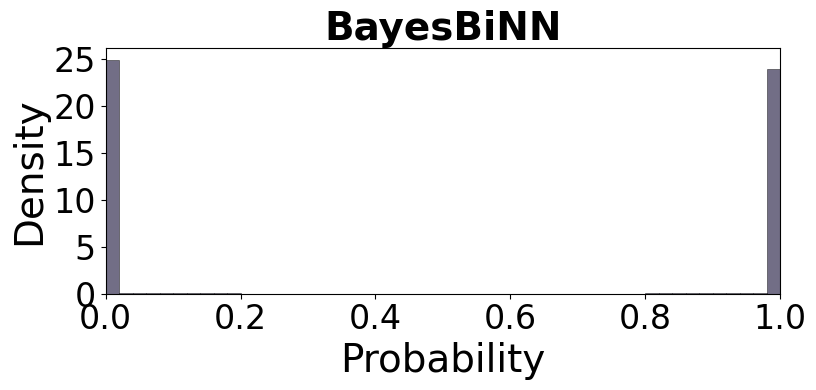

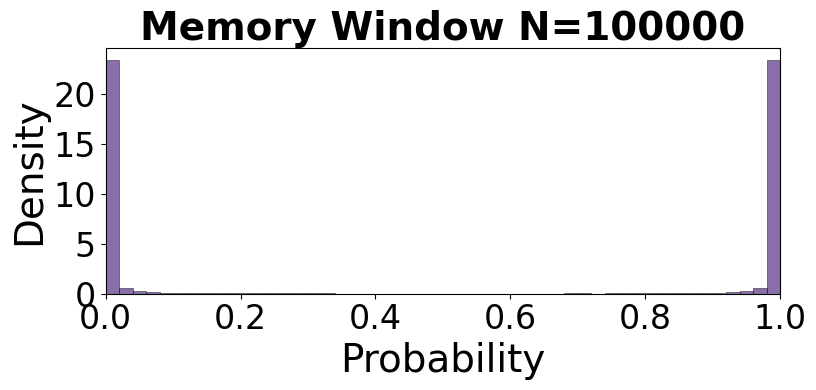

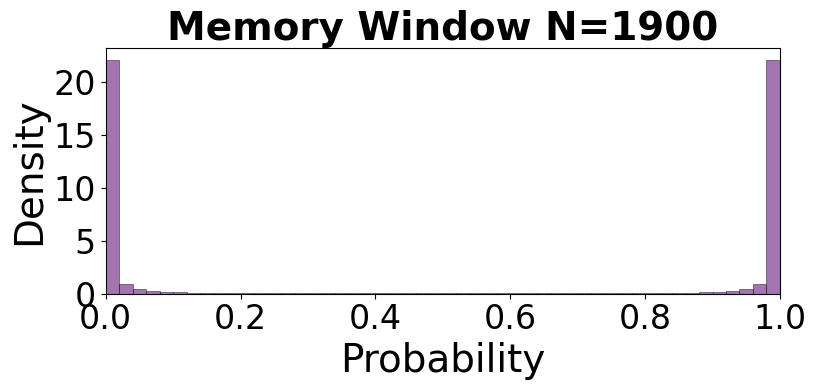

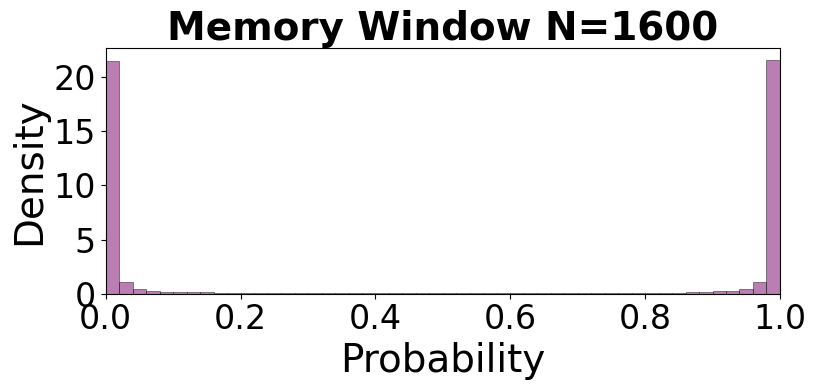

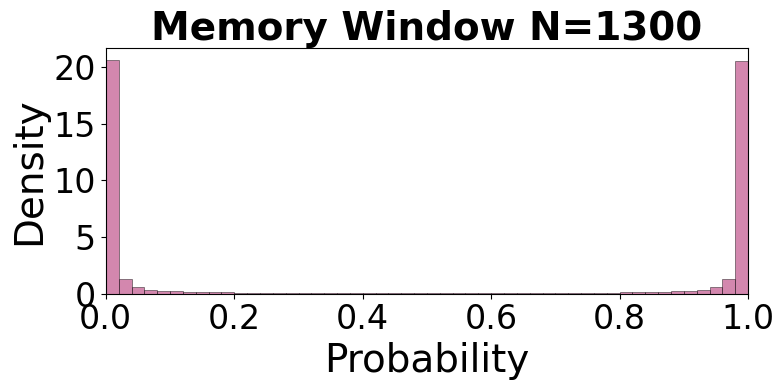

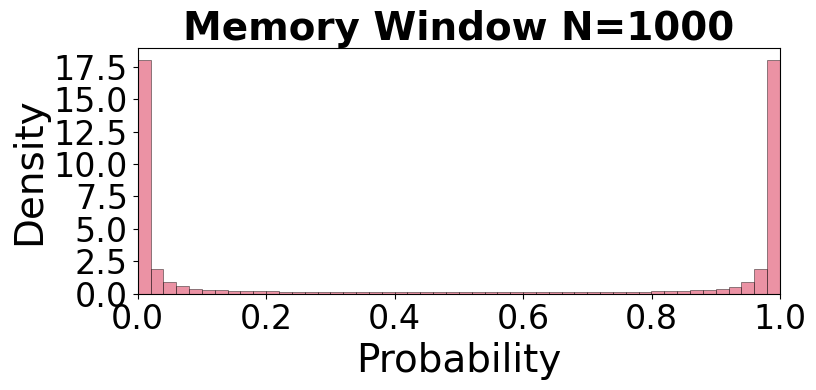

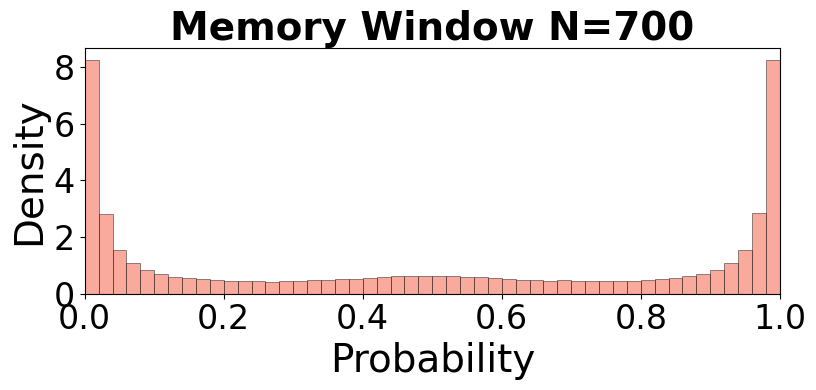

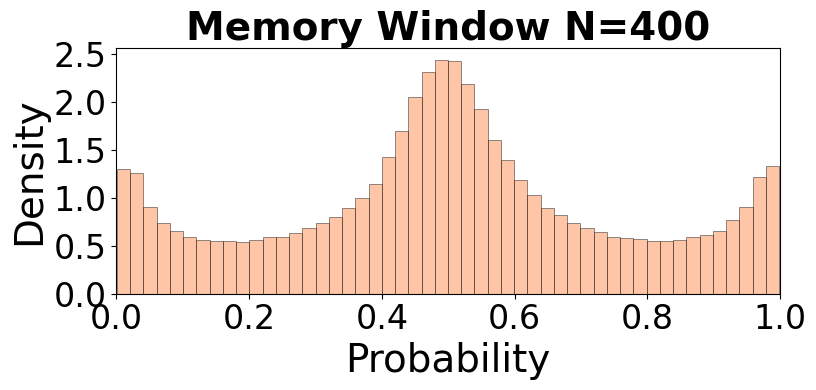

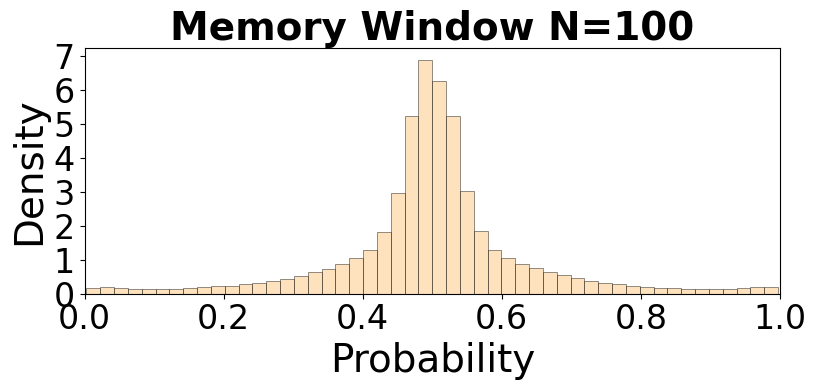

In [6]:
# Sort by numeric value of N (N stored as string)
df["N_num"] = pd.to_numeric(df["N"], errors="coerce")  # non-numeric (e.g. "none") -> NaN
df = df.sort_values(by="N_num", na_position="last", ascending=False).reset_index(drop=True)
N_values = df["N"].unique()
n_N = len(N_values)

# Choose a color palette
palette = sns.color_palette("magma", n_N)

# Loop over each N and create a separate figure (histogram)
for i, n in enumerate(N_values):
    expected_weights = df[df["N"] == n]["expected_weights"].values[0]  # assuming one row per N
    weights = jnp.ravel(expected_weights).tolist()  # convert to flat Python list for matplotlib

    plt.figure(figsize=(8, 4))
    plt.hist(
        weights,
        bins=50,
        density=True,
        color=palette[i],
        alpha=0.6,
        edgecolor="k",
        linewidth=0.5
    )
    
    # Titles and labels
    if n == "1000000000":
        plt .title(f"BayesBiNN", fontsize=AXESSIZE, weight='bold')
    else:
        plt.title(f"Memory Window N={n}", fontsize=AXESSIZE, weight='bold')
    plt.xlabel("Probability", fontsize=AXESSIZE)
    plt.ylabel("Density", fontsize=AXESSIZE)

    # Ticks styling
    plt.xticks(fontsize=TICKSIZE)
    plt.yticks(fontsize=TICKSIZE)
    
    # Tight layout
    plt.tight_layout()
    
    plt.xlim(0, 1)
    
    # Save each figure separately for Inkscape
    plt.savefig(f"{FOLDER}/hist_N_{n}.svg", format='svg')